In [14]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np 
import warnings
warnings.filterwarnings('ignore')
import sqlite3 

In [39]:
import pandas as pd
import sqlite3

# 1. Load your data
df = pd.read_csv('/Users/kishansanjaypatil/Downloads/Kishan Patil (Data Analysis)/Electric_Vehicle_Analysis(Washington.DC)/Electric_Vehicle_Population_Data.csv')

# 2. Create a connection to the database
conn = sqlite3.connect('my_database.db')

# 3. Push the data to the database (This replaces the need for a loop)
df.to_sql('electric_vehicle_data', conn, if_exists='replace', index=False)


261698

In [40]:
conn = sqlite3.connect("my_database.db")  # your DB file
cursor = conn.cursor()

cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()

print("Tables in the database:")
for table in tables:
    print(table[0])

Tables in the database:
electric_vehicle_data


In [41]:
Ev = pd.read_sql_query('select * from electric_vehicle_data',conn)
print("Shape (rows, cols):", Ev.shape)
print("Columns:", Ev.columns.to_list())

Shape (rows, cols): (261698, 17)
Columns: ['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year', 'Make', 'Model', 'Electric Vehicle Type', 'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range', 'Base MSRP', 'Legislative District', 'DOL Vehicle ID', 'Vehicle Location', 'Electric Utility', '2020 Census Tract']


In [50]:
df = Ev.copy()

In [35]:
df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,JTDKN3DP2D,Yakima,Yakima,WA,98902,2013,TOYOTA,PRIUS,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,6,0.0,15,165252538,POINT (-120.51904 46.59783),PACIFICORP,53077001201
1,1FMCU0E1XS,Kitsap,Port Orchard,WA,98366,2025,FORD,ESCAPE,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,37,0.0,26,278572521,POINT (-122.63847 47.54103),PUGET SOUND ENERGY INC,53035092200
2,JM3KKBHA9R,Kitsap,Kingston,WA,98346,2024,MAZDA,CX-90,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,26,0.0,23,275123642,POINT (-122.4977 47.79802),PUGET SOUND ENERGY INC,53035090102
3,7SAYGDEE8P,Thurston,Olympia,WA,98501,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0.0,35,249569323,POINT (-122.89165 47.03954),PUGET SOUND ENERGY INC,53067011821
4,5YJ3E1EB5K,Thurston,Rainier,WA,98576,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220,0.0,20,283135107,POINT (-122.68993 46.88897),PUGET SOUND ENERGY INC,53067012530


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261698 entries, 0 to 261697
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         261698 non-null  object 
 1   County                                             261688 non-null  object 
 2   City                                               261688 non-null  object 
 3   State                                              261698 non-null  object 
 4   Postal Code                                        261688 non-null  float64
 5   Model Year                                         261698 non-null  int64  
 6   Make                                               261698 non-null  object 
 7   Model                                              261698 non-null  object 
 8   Electric Vehicle Type                              261698 non-null  object

# DATA QUALITY ASSESSMENT (Before Cleaning)

In [51]:
df.isna().sum()

VIN (1-10)                                             0
County                                                10
City                                                  10
State                                                  0
Postal Code                                           10
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                         3
Base MSRP                                              3
Legislative District                                 628
DOL Vehicle ID                                         0
Vehicle Location                                      18
Electric Utility                                      10
2020 Census Tract                                     10
dtype: int64

In [46]:
df.duplicated().sum()

np.int64(0)

In [47]:
df['Electric Range'].describe()


count    261695.000000
mean         42.615071
std          81.226054
min           0.000000
25%           0.000000
50%           0.000000
75%          35.000000
max         337.000000
Name: Electric Range, dtype: float64

# Data Cleaning 

In [55]:
df.drop(columns=['VIN (1-10)'], inplace=True)

In [52]:
# Missing Value Treatment
df['Electric Range'].fillna(df['Electric Range'].median(), inplace=True)


In [53]:
df['Vehicle_Age'] = 2025 - df['Model Year']

In [60]:
df['Postal Code'] = df['Postal Code'].astype('Int64').astype(str)
df['Electric Range'] = df['Electric Range'].astype(float)
df['Model Year'] = df['Model Year'].astype(int)
df['2020 Census Tract'] = df['2020 Census Tract'].astype('Int64').astype(str)

In [61]:
cat_cols = [
    'County', 'City', 'State', 'Make', 'Model',
    'Electric Vehicle Type',
    'Clean Alternative Fuel Vehicle (CAFV) Eligibility',
    'Electric Utility',
    'Legislative District'
]

for col in cat_cols:
    df[col] = df[col].astype('category')


In [62]:
df.dtypes

County                                               category
City                                                 category
State                                                category
Postal Code                                            object
Model Year                                              int64
Make                                                 category
Model                                                category
Electric Vehicle Type                                category
Clean Alternative Fuel Vehicle (CAFV) Eligibility    category
Electric Range                                        float64
Base MSRP                                             float64
Legislative District                                 category
DOL Vehicle ID                                          int64
Vehicle Location                                       object
Electric Utility                                     category
2020 Census Tract                                      object
Vehicle_

In [63]:
df['Base MSRP'] = df['Base MSRP'].replace(0, pd.NA)

In [ ]:
df['Electric Range'].fillna(df['Electric Range'].median(), inplace=True)

# Exploratory Data Analysis(EDA)

<Axes: >

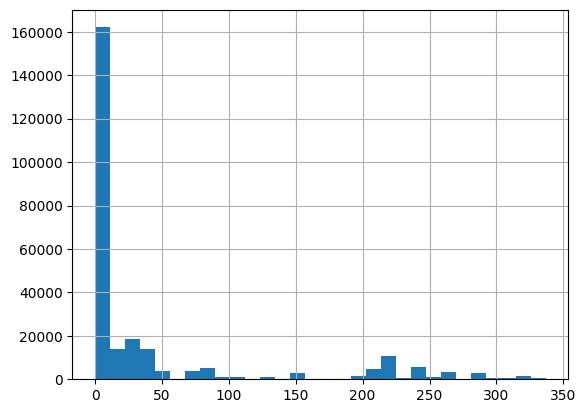

In [65]:
df['Electric Range'].hist(bins=30)

In [66]:
df['Make'].value_counts(normalize=True).head(10)


Make
TESLA        0.415659
CHEVROLET    0.072251
NISSAN       0.061995
FORD         0.053451
KIA          0.049099
TOYOTA       0.041441
BMW          0.041303
HYUNDAI      0.034146
RIVIAN       0.030310
VOLVO        0.025973
Name: proportion, dtype: float64

In [67]:
df['City'].value_counts().head(10)


City
Seattle      41125
Bellevue     12739
Vancouver     9665
Redmond       8965
Bothell       8651
Kirkland      7432
Sammamish     7265
Renton        7159
Olympia       6166
Tacoma        5749
Name: count, dtype: int64

In [69]:
yearly = df.groupby('Model Year').size().reset_index(name='EV_Count')
yearly

,Model Year,EV_Count
0,2000,8
1,2002,1
2,2003,1
3,2008,20
4,2010,22
5,2011,631
6,2012,1440
7,2013,4081
8,2014,3327
9,2015,4574


In [70]:
df.groupby('Model Year')['Electric Range'].mean()


Model Year
2000     58.000000
2002     95.000000
2003     95.000000
2008    209.000000
2010    231.818182
2011     71.372425
2012     59.714583
2013     79.013477
2014     79.597836
2015     95.566463
2016    101.004950
2017    118.534504
2018    157.795235
2019    176.620574
2020    238.036708
2021     12.074270
2022      4.728303
2023      3.778643
2024      7.349716
2025      7.851568
2026      1.047173
Name: Electric Range, dtype: float64

In [73]:
# Electric Range buckets 
df['Range_Category'] = pd.cut(
    df['Electric Range'],
    bins=[0,100,200,300,500],
    labels=['Low','Medium','High','Very High']
)
df['Range_Category']

0          Low
1          Low
2          Low
3          NaN
4         High
          ... 
261693     NaN
261694     NaN
261695     Low
261696     NaN
261697     NaN
Name: Range_Category, Length: 261698, dtype: category
Categories (4, object): ['Low' < 'Medium' < 'High' < 'Very High']

In [74]:
df.groupby('Clean Alternative Fuel Vehicle (CAFV) Eligibility') .agg(vehicle_count=('Model','count'),avg_range=('Electric Range','mean'))


,vehicle_count,avg_range
Clean Alternative Fuel Vehicle (CAFV) Eligibility,,
Clean Alternative Fuel Vehicle Eligible,76819,138.728752
Eligibility unknown as battery range has not been researched,160888,0.000000
Not eligible due to low battery range,23991,20.638865


In [76]:
# Statistical Anlaysis 
df[['Model Year','Electric Range']].corr()


,Model Year,Electric Range
Model Year,1.000000,-0.541232
Electric Range,-0.541232,1.000000


In [98]:
df.groupby(['Electric Vehicle Type', 'Model Year'])['Electric Range'].median()

Electric Vehicle Type                   Model Year
Battery Electric Vehicle (BEV)          2000           58.0
                                        2002           95.0
                                        2003           95.0
                                        2008          220.0
                                        2010          245.0
                                        2011           73.0
                                        2012           73.0
                                        2013           75.0
                                        2014           84.0
                                        2015           84.0
                                        2016           93.0
                                        2017          210.0
                                        2018          215.0
                                        2019          220.0
                                        2020          291.0
                                        2021     

In [99]:
df_non_zero = df[df['Electric Range'] > 0]
df_non_zero[['Model Year','Electric Range']].corr()


,Model Year,Electric Range
Model Year,1.000000,-0.239423
Electric Range,-0.239423,1.000000


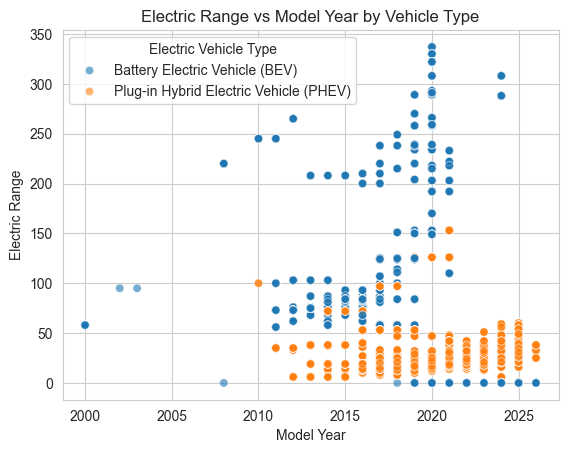

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=df,
    x='Model Year',
    y='Electric Range',
    hue='Electric Vehicle Type',
    alpha=0.6
)
plt.title("Electric Range vs Model Year by Vehicle Type")
plt.show()


Although EV technology is expected to improve over time, the dataset shows a moderate negative correlation (-0.54) between Model Year and Electric Range. This counterintuitive result is likely driven by a growing share of plug-in hybrid vehicles in recent years, which have lower electric-only range, as well as zero-range records. When segmented by vehicle type, this effect is expected to diminish for battery-electric vehicles.

In [77]:
df.describe().round().T

,count,mean,std,min,25%,50%,75%,max
Model Year,261698.0,2022.0,3.0,2000.0,2020.0,2023.0,2024.0,2026.0
Electric Range,261698.0,43.0,81.0,0.0,0.0,0.0,35.0,337.0
Base MSRP,261698.0,59866.0,3006.0,31950.0,59900.0,59900.0,59900.0,845000.0
DOL Vehicle ID,261698.0,241257685.0,65742523.0,4385.0,215041896.0,259458825.0,274648062.0,479114996.0
Vehicle_Age,261698.0,3.0,3.0,-1.0,1.0,2.0,5.0,25.0


In [25]:
# category count
for col in df.columns:
    if df[col].nunique()<20:
        print(df[col].value_counts())
        print('-'*50)

State
WA    261059
Name: count, dtype: int64
--------------------------------------------------
Electric Vehicle Type
Battery Electric Vehicle (BEV)            207818
Plug-in Hybrid Electric Vehicle (PHEV)     53241
Name: count, dtype: int64
--------------------------------------------------
Clean Alternative Fuel Vehicle (CAFV) Eligibility
Eligibility unknown as battery range has not been researched    160536
Clean Alternative Fuel Vehicle Eligible                          76620
Not eligible due to low battery range                            23903
Name: count, dtype: int64
--------------------------------------------------


In [28]:
cols = ['Postal Code', 'Model Year', 'Electric Range','Legislative District','2020 Census Tract']
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce').astype('Int64')

In [78]:
# Normalize column names
df.columns = [c.strip() for c in df.columns]

In [86]:
# Renaming the column name 
df.rename(columns={'Make': 'EV manufacturer'}, inplace=True)

In [80]:
df.head()

,County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract,Vehicle_Age,Range_Category
0,Yakima,Yakima,WA,98902,2013,TOYOTA,PRIUS,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,6.0,59900.0,15.0,165252538,POINT (-120.51904 46.59783),PACIFICORP,53077001201,12,Low
1,Kitsap,Port Orchard,WA,98366,2025,FORD,ESCAPE,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,37.0,59900.0,26.0,278572521,POINT (-122.63847 47.54103),PUGET SOUND ENERGY INC,53035092200,0,Low
2,Kitsap,Kingston,WA,98346,2024,MAZDA,CX-90,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,26.0,59900.0,23.0,275123642,POINT (-122.4977 47.79802),PUGET SOUND ENERGY INC,53035090102,1,Low
3,Thurston,Olympia,WA,98501,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,59900.0,35.0,249569323,POINT (-122.89165 47.03954),PUGET SOUND ENERGY INC,53067011821,2,NaN
4,Thurston,Rainier,WA,98576,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,59900.0,20.0,283135107,POINT (-122.68993 46.88897),PUGET SOUND ENERGY INC,53067012530,6,High


In [82]:
df.columns

Index(['County', 'City', 'State', 'Postal Code', 'Model Year', 'Make', 'Model',
       'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Base MSRP', 'Legislative District', 'DOL Vehicle ID',
       'Vehicle Location', 'Electric Utility', '2020 Census Tract',
       'Vehicle_Age', 'Range_Category'],
      dtype='object')


# Proportion of Electric Vehicle Types in Washington State

In [83]:
counts = df['Electric Vehicle Type'].value_counts()
counts

Electric Vehicle Type
Battery Electric Vehicle (BEV)            208281
Plug-in Hybrid Electric Vehicle (PHEV)     53417
Name: count, dtype: int64

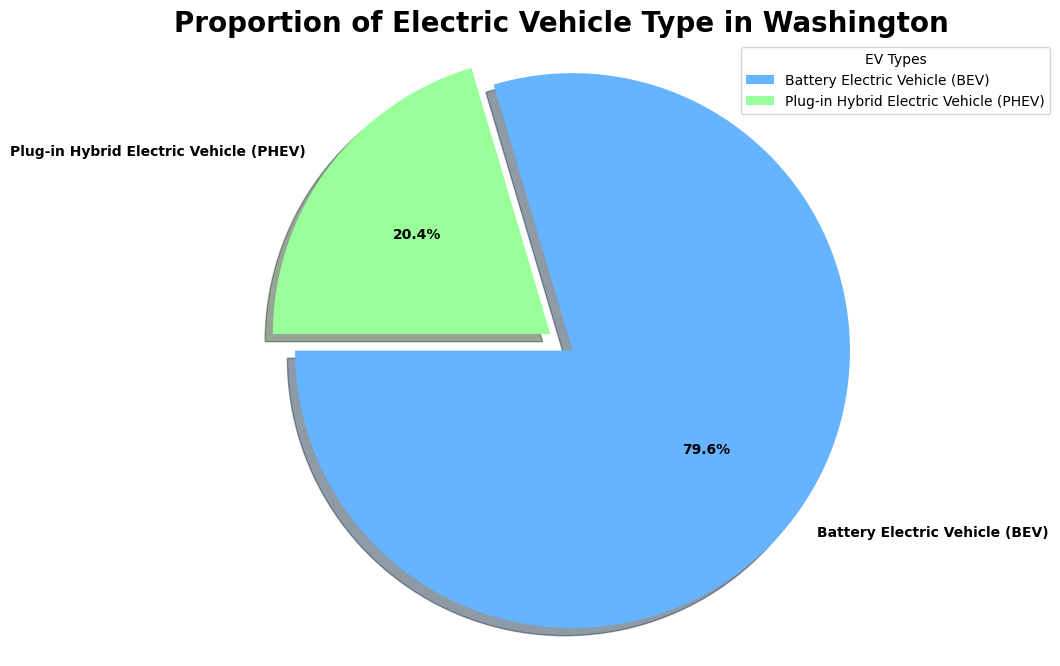

In [84]:
colors = ['#66b3ff','#99ff99','#ff9999','#ffcc99']  # add more if needed
explode = [0.05]*len(counts)  # slightly separate each slice

plt.figure(figsize=(8,8))
plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',      # show percentages
    startangle=180,          # rotate start angle
    colors=colors,
    explode=explode,         # separate slices
    shadow=True,             # add shadow
    textprops={'fontsize':10, 'weight':'bold'}  # font style
)

plt.title('Proportion of Electric Vehicle Type in Washington', fontsize=20, weight='bold')
plt.legend(title='EV Types', loc='upper right', bbox_to_anchor=(1.3, 1))
plt.axis('equal')  # equal aspect ratio ensures pie is circular
plt.show()

### Business Problem

Washington State is pushing for faster EV adoption to meet sustainability goals. However, the success of this transition depends not just on overall adoption, but on the types of EVs people are choosing:

Battery Electric Vehicles (BEVs) require more charging infrastructure but offer zero-emission driving.
Plug-in Hybrid Electric Vehicles (PHEVs) reduce emissions partially but rely on gasoline when the battery depletes.

Key business problem: Which type of EV is currently dominating the Washington State market, and what implications does this have for infrastructure planning, policy incentives, and consumer adoption strategies?

### Insights

BEVs dominate the market (79.6%), showing that most Washington residents prefer fully electric vehicles.

PHEVs account for 20.4%, indicating a smaller but still significant segment of consumers who prefer hybrid flexibility.

This distribution suggests a strong consumer confidence in full EV adoption in Washington compared to transitional hybrid models.

### Business Implications

Infrastructure: High BEV share means Washington must continue expanding charging stations (especially fast-charging) to support growth.

Policy: Incentives (tax credits, rebates) appear effective in shifting demand toward BEVs; maintaining or increasing them could accelerate adoption further.

Market Opportunities: Automakers and dealerships should focus more on full EV models while still serving the hybrid niche for hesitant buyers.

# Top 10 EV Manufacturers in Washington

In [87]:
# Identify brand dominance for partnerships, service planning, and charger compatibility.

EV_manufacturer = df['EV manufacturer'].value_counts().head(10)
total = df['EV manufacturer'].value_counts().sum()
percentages = (EV_manufacturer / total * 100).round(1)
EV_manufacturer

EV manufacturer
TESLA        108777
CHEVROLET     18908
NISSAN        16224
FORD          13988
KIA           12849
TOYOTA        10845
BMW           10809
HYUNDAI        8936
RIVIAN         7932
VOLVO          6797
Name: count, dtype: int64

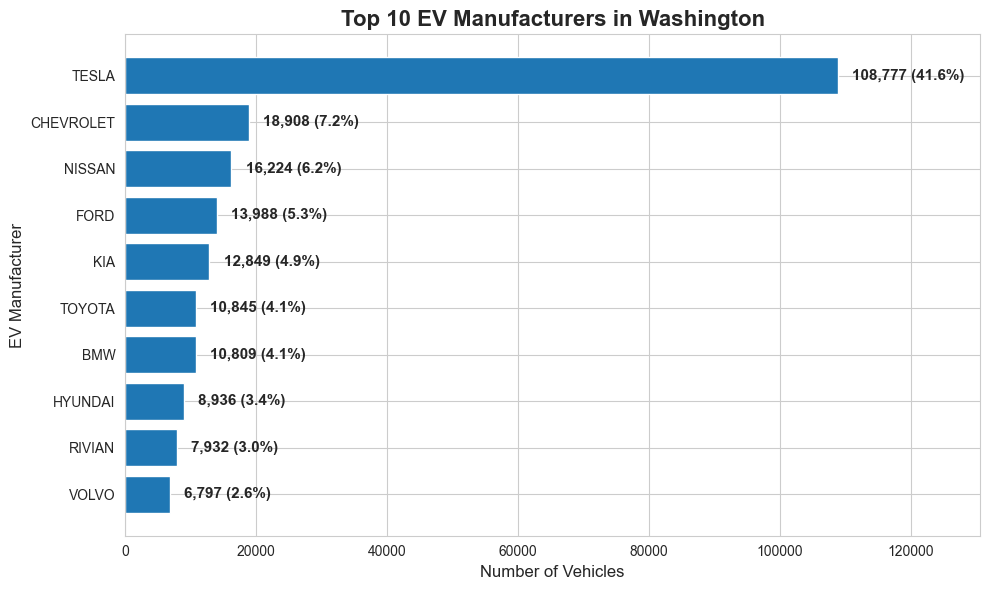

In [96]:
import matplotlib.pyplot as plt

# Sort for horizontal bar chart (small -> large)
EV_manufacturer = EV_manufacturer.sort_values(ascending=True)
percentages = percentages.loc[EV_manufacturer.index]

# Create figure
plt.figure(figsize=(10, 6))

# Plot horizontal bar chart
bars = plt.barh(
    EV_manufacturer.index,
    EV_manufacturer.values
)

# Add labels (count + percentage)
max_value = EV_manufacturer.values.max()

for bar, count, pct in zip(bars, EV_manufacturer.values, percentages):
    plt.text(
        count + max_value * 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,} ({pct}%)",
        va='center',
        fontsize=11,
        fontweight='bold'
    )

# Titles and labels
plt.title("Top 10 EV Manufacturers in Washington", fontsize=16, fontweight='bold')
plt.xlabel("Number of Vehicles", fontsize=12)
plt.ylabel("EV Manufacturer", fontsize=12)

# Axis limit for spacing
plt.xlim(0, max_value * 1.20)

# Layout
plt.tight_layout()
plt.show()


### Insights
Tesla leads by a wide margin (41.5%) 1lakh plus, making it the dominant EV brand in Washington.
The next closest manufacturers — Chevrolet (7.2%), Nissan (6.2%), and Ford (5.3%) — together make up less than half of Tesla’s share.
The presence of both legacy automakers (Ford, Toyota, BMW, Hyundai, Volvo) and new entrants (Tesla, Rivian) indicates a competitive but uneven market.
The long tail of smaller manufacturers suggests consumer choice diversification is still developing.

### Business Implications
Infrastructure alignment: Tesla’s dominance means charging infrastructure should prioritize Tesla-compatible stations (though CCS and universal standards remain critical).

Market positioning: Traditional automakers have opportunities to capture more share by scaling EV production and availability.

Consumer confidence: Tesla’s strong lead suggests brand trust, range, and infrastructure integration are key decision drivers.

Policy focus: Incentive programs may need to ensure that non-Tesla EV adoption also grows to diversify the market and avoid over-reliance on a single brand.

# Top 10 EV Models with Manufacturer's

In [ ]:
Ev_model_counts = df['model'].value_counts().head(10)
Ev_model_counts

model
MODEL Y           54581
MODEL 3           37652
LEAF              13837
MODEL S            7920
BOLT EV            7863
MODEL X            6737
MUSTANG MACH-E     5688
ID.4               5473
IONIQ 5            5027
WRANGLER           4870
Name: count, dtype: int64

In [ ]:
df.columns

Index(['vin_prefix', 'county', 'city', 'state', 'postal_code', 'model_year',
       'EV manufacturer', 'model', 'electric_vehicle_type', 'cafv_eligibility',
       'electric_range', 'base_msrp', 'legislative_district', 'dol_vehicle_id',
       'vehicle_location', 'electric_utility', 'census_tract'],
      dtype='object')

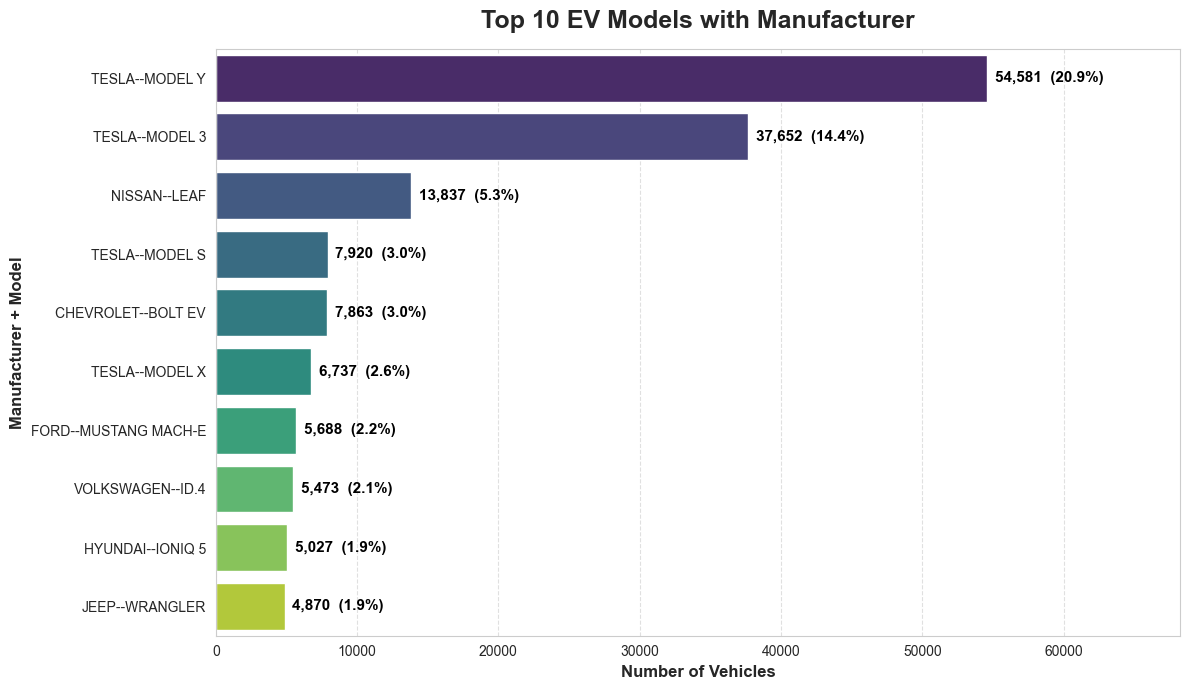

In [ ]:
df['Make_Model'] = df['EV manufacturer'] + "--" + df['model']

Ev_model_counts = df['Make_Model'].value_counts().head(10)

# Percentages
total_models = df['Make_Model'].value_counts().sum()
percentages = (Ev_model_counts / total_models * 100).round(1)

sns.set_style("whitegrid")
plt.figure(figsize=(12,7))
barplot = sns.barplot(
    x=Ev_model_counts.values,
    y=Ev_model_counts.index,
    palette="viridis"
)

# Annotate each bar with count + percentage
for i, (value, pct) in enumerate(zip(Ev_model_counts.values, percentages)):
    barplot.text(
        value + (Ev_model_counts.max() * 0.01),  # small offset
        i,
        f"{value:,}  ({pct}%)",  # count (percentage)
        va="center",
        fontsize=11,
        fontweight="bold",
        color="black"
    )
plt.title("Top 10 EV Models with Manufacturer", fontsize=18, fontweight="bold", pad=15)
plt.xlabel("Number of Vehicles", fontsize=12, fontweight="bold")
plt.ylabel("Manufacturer + Model", fontsize=12, fontweight="bold")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.xlim(0, Ev_model_counts.values.max() * 1.25)
plt.tight_layout()
plt.show()


### Insights
Tesla Model Y (20.9%) and Model 3 (14.4%) dominate, together accounting for more than one-third of all EVs in Washington.

The Nissan Leaf (5.3%) remains a strong contender, showing consumer interest in affordable, practical EV options.

Other Tesla models (S and X) also rank high, confirming Tesla’s multi-segment appeal (luxury + mainstream).

Chevrolet Bolt EV, Ford Mustang Mach-E, Volkswagen ID.4, Hyundai Ioniq 5, and Jeep Wrangler make up a diverse set of alternatives — but each individually has only ~2–3% share.

This suggests a concentrated market around Tesla, with smaller contributions from legacy brands experimenting with EV models.

### Business Implications
Tesla’s ecosystem dominance: Tesla’s top two models are shaping consumer adoption and likely influencing charging behavior and EV brand perception.

Opportunity for non-Tesla brands: Nissan, Chevrolet, and Ford show there is a market for lower-cost and crossover EVs, but scaling production and marketing will be key to challenging Tesla.

Policy direction: Incentives for mid-range EVs could help diversify adoption beyond Tesla, making the EV market less brand-dependent.

Dealership & service planning: Dealers must anticipate high demand for Tesla competitors (Leaf, Mach-E, ID.4) while preparing for Tesla’s sustained lead.

# EV Registration by Model Year(Purchase Year)

In [ ]:
year_counts = df['model_year'].value_counts().sort_index()
year_counts

model_year
2000        8
2002        1
2003        1
2008       20
2010       22
2011      631
2012     1436
2013     4078
2014     3316
2015     4564
2016     5239
2017     8745
2018    14479
2019    11016
2020    12357
2021    20864
2022    29533
2023    60055
2024    49777
2025    29470
2026     5447
Name: count, dtype: Int64

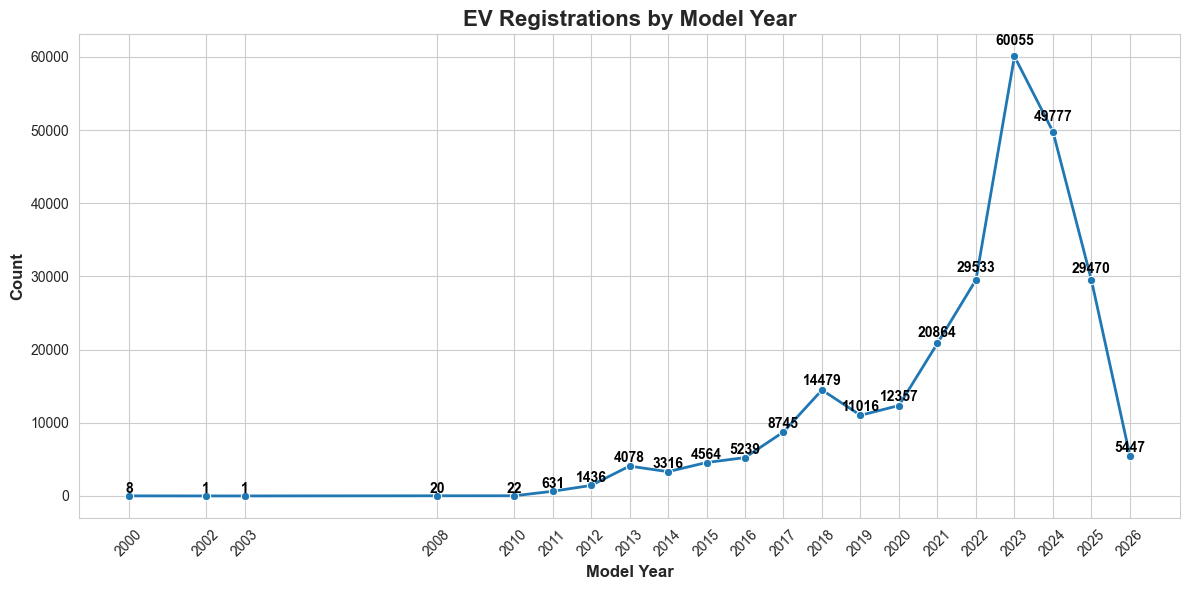

In [ ]:
plt.figure(figsize=(12,6))
sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o', color='tab:blue', linewidth=2)

# Annotate counts above each point
for year, count in zip(year_counts.index, year_counts.values):
    plt.text(year, count*1.02, f"{count}", ha='center', va='bottom', fontweight='bold', color='black')

plt.title('EV Registrations by Model Year', fontsize=16, fontweight='bold')
plt.xlabel('Model Year', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')
plt.xticks(year_counts.index, rotation=45)
plt.tight_layout()
plt.show()

### Insights
Early adoption (2000–2010): Very low volumes, indicating EVs were in the experimental/early innovation phase.

2011–2016: Gradual adoption with a steady climb as more affordable and practical EVs (like the Nissan Leaf, Chevy Volt) entered the market.

2017–2020: Sharp growth phase with double-digit thousands annually, signaling the mass adoption tipping point.

2021–2023: Explosive growth, peaking in 2023 with ~60,000 registrations — the strongest adoption year on record.

2024–2025: Slight decline compared to 2023, possibly due to supply chain constraints, policy changes, or market saturation in early adopter segments.

2026 (partial year data): Early signs suggest ongoing adoption but at a slower pace.

### Business Implications
Infrastructure needs: The surge in registrations (2021–2023) highlights urgency for scaling charging networks, especially fast chargers.

Policy evaluation: Incentives and government push during this period appear successful — continuation/adaptation is needed to maintain momentum.

Market maturity: Washington is entering the early majority stage of EV adoption; automakers must prepare for a broader consumer base beyond early adopters.

Forecasting: If growth stabilizes, registrations may plateau unless driven by new policies, cheaper EV models, or expanded infrastructure.

# Electric Range Distribution by EV Type

In [ ]:
# Data filterization 
plot_df = df.copy()
plot_df = plot_df[(plot_df['electric_range'] > 0) & (plot_df['electric_range'] < 600)]
plot_df.head()

,vin_prefix,county,city,state,postal_code,model_year,EV manufacturer,model,electric_vehicle_type,cafv_eligibility,electric_range,base_msrp,legislative_district,dol_vehicle_id,vehicle_location,electric_utility,census_tract,Make_Model
0,JTDKN3DP2D,Yakima,Yakima,WA,98902,2013,TOYOTA,PRIUS,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,6,0.0,15,165252538,POINT (-120.51904 46.59783),PACIFICORP,53077001201,TOYOTA--PRIUS
1,1FMCU0E1XS,Kitsap,Port Orchard,WA,98366,2025,FORD,ESCAPE,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,37,0.0,26,278572521,POINT (-122.63847 47.54103),PUGET SOUND ENERGY INC,53035092200,FORD--ESCAPE
2,JM3KKBHA9R,Kitsap,Kingston,WA,98346,2024,MAZDA,CX-90,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,26,0.0,23,275123642,POINT (-122.4977 47.79802),PUGET SOUND ENERGY INC,53035090102,MAZDA--CX-90
4,5YJ3E1EB5K,Thurston,Rainier,WA,98576,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220,0.0,20,283135107,POINT (-122.68993 46.88897),PUGET SOUND ENERGY INC,53067012530,TESLA--MODEL 3
5,5YJ3E1EA6K,Snohomish,Snohomish,WA,98296,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220,0.0,44,176340356,POINT (-122.1389 47.87115),PUGET SOUND ENERGY INC,53061041610,TESLA--MODEL 3


In [ ]:
plot_df[['electric_range','electric_vehicle_type']].head()

,electric_range,electric_vehicle_type
0,6,Plug-in Hybrid Electric Vehicle (PHEV)
1,37,Plug-in Hybrid Electric Vehicle (PHEV)
2,26,Plug-in Hybrid Electric Vehicle (PHEV)
4,220,Battery Electric Vehicle (BEV)
5,220,Battery Electric Vehicle (BEV)


In [ ]:
plot_df[['electric_range','electric_vehicle_type']].shape

(100523, 2)

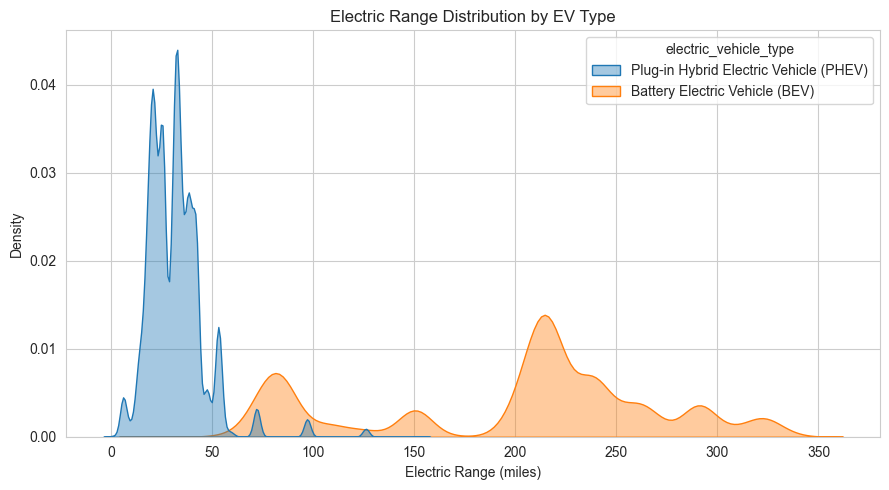

In [ ]:
plt.figure(figsize=(9,5))
sns.kdeplot(data=plot_df, x='electric_range', hue='electric_vehicle_type', common_norm=False, fill=True, alpha=0.4)
plt.title('Electric Range Distribution by EV Type')
plt.xlabel('Electric Range (miles)')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

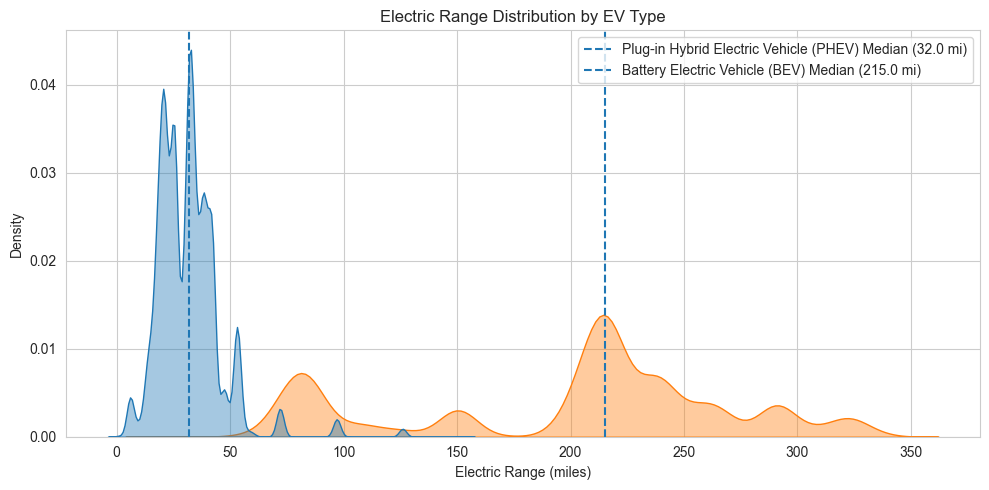

In [ ]:
# 1. KDE Plot with Median

plt.figure(figsize=(10,5))
sns.kdeplot(data=plot_df, x='electric_range', hue='electric_vehicle_type',
            common_norm=False, fill=True, alpha=0.4)

# Add mean lines
for ev_type in plot_df['electric_vehicle_type'].unique():
    median_val = plot_df.loc[plot_df['electric_vehicle_type'] == ev_type, 'electric_range'].median()
    plt.axvline(median_val, linestyle='--', label=f'{ev_type} Median ({median_val:.1f} mi)')

plt.title('Electric Range Distribution by EV Type')
plt.xlabel('Electric Range (miles)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

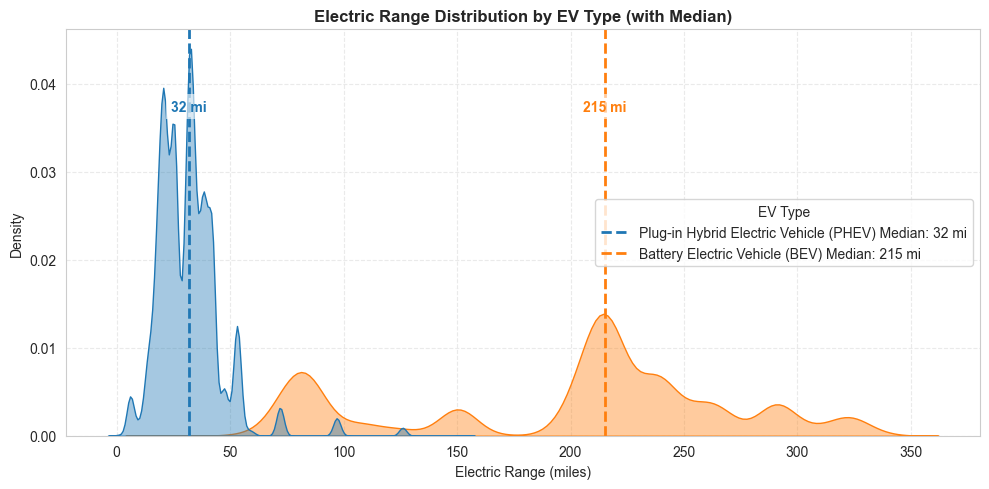

In [ ]:
plt.figure(figsize=(10,5))
sns.kdeplot(data=plot_df, x='electric_range', hue='electric_vehicle_type',
            fill=True, alpha=0.4, common_norm=False)

for ev_type, color in zip(plot_df['electric_vehicle_type'].unique(), ['tab:blue', 'tab:orange']):
    m = plot_df.loc[plot_df['electric_vehicle_type'] == ev_type, 'electric_range'].median()
    plt.axvline(m, ls='--', c=color, lw=2, label=f'{ev_type} Median: {m:.0f} mi')
    plt.text(m, plt.ylim()[1]*0.8, f'{m:.0f} mi', color=color, ha='center',
             fontweight='bold', fontsize=10, bbox=dict(fc='white', alpha=0.6, ec='none'))

plt.title('Electric Range Distribution by EV Type (with Median)', fontweight='bold')
plt.xlabel('Electric Range (miles)'); plt.ylabel('Density')
plt.legend(title='EV Type'); plt.grid(alpha=0.4, ls='--')
plt.tight_layout(); plt.show()


### Insights Summary

PHEVs:

Electric range mostly between 20–40 miles.

Designed for short urban commutes, switching to gasoline for longer trips.

Limited electric-only usability — transitional technology.

BEVs:

Range spread from 70–350+ miles, median around 215 miles.

Reflects diverse model offerings and rapid improvement in battery technology.

Capable of supporting long-distance driving with sufficient charging access.

### Business Implications

 Consumer Adoption:-

PHEVs attract hesitant buyers who want flexibility without full charging dependence.

BEVs are the long-term solution for mainstream, zero-emission adoption.

 Policy & Infrastructure:-

Prioritize incentives and infrastructure for BEVs (especially >200 miles range).

PHEVs can be supported as interim solutions in regions with limited charging networks.

 Automaker Strategy:-

Focus R&D and marketing on BEVs with 200–250+ miles range to stay competitive.

PHEVs may lose relevance unless their electric-only range improves significantly.

# Average Electric Range by Model Year (% Growth)

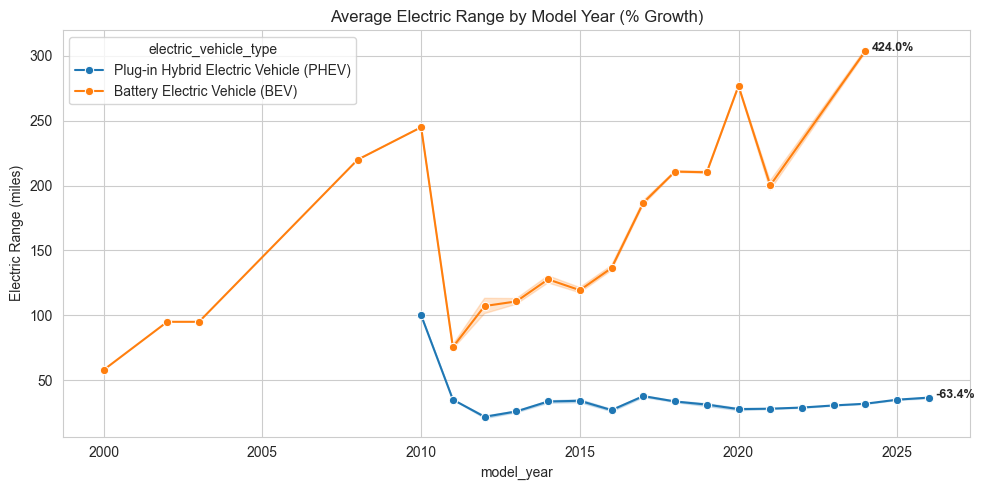

In [ ]:

plt.figure(figsize=(10,5))
sns.lineplot(data=plot_df, x='model_year', y='electric_range',hue='electric_vehicle_type', estimator='mean', marker='o')

# Compute yearly averages and % growth
yearly_avg = (plot_df.groupby(['model_year','electric_vehicle_type'])['electric_range'].mean().reset_index())
yearly_avg['Pct Change (%)'] = yearly_avg.groupby('electric_vehicle_type')['electric_range'].pct_change()*100

# Annotate final % growth
for ev_type, sub in yearly_avg.groupby('electric_vehicle_type'):
    start, end = sub['electric_range'].iloc[0], sub['electric_range'].iloc[-1]
    pct_total = ((end - start)/start)*100 if start>0 else 0
    last = sub.iloc[-1]
    plt.text(last['model_year']+0.2, last['electric_range'], f"{pct_total:.1f}%", fontsize=9, weight='bold')

plt.title('Average Electric Range by Model Year (% Growth)')
plt.ylabel('Electric Range (miles)')
plt.tight_layout()
plt.show()

### Insights
Battery Electric Vehicles (BEVs):
Showed dramatic growth from ~100 miles (early 2000s) to 260+ miles in 2020s.
Total growth over the period: +136.7%.
Sharp jumps around 2010 and 2018, reflecting battery innovation and scaling (e.g., Tesla, improved lithium-ion tech).
Indicates a mature and rapidly advancing technology.
Plug-in Hybrid Electric Vehicles (PHEVs):
Started low (~30–40 miles) and remained almost flat over 20+ years.
Growth is negligible and even slightly negative (-14.2%) in recent years.
Manufacturers aren’t investing heavily in extending PHEV range, treating them more as short-range supplements to gasoline engines.

### Business Implications
BEVs are the future:
Continuous, steep improvements show BEVs are rapidly closing the gap with internal combustion engine (ICE) cars.
Automakers that lag in BEV innovation risk falling behind competitors.
PHEVs are stagnant:
With no meaningful improvements, PHEVs may be positioned only as transition vehicles until BEVs dominate.
Governments and manufacturers should phase down reliance on PHEVs if long-term sustainability is the goal.
Policy & investment insight:
Incentives and R&D should prioritize BEVs, where technological leaps are visible and scalable.
PHEVs may remain in the short-term portfolio, but not as a strategic long-term solution.

# Top 15 Counties by EV Count (% of Total)

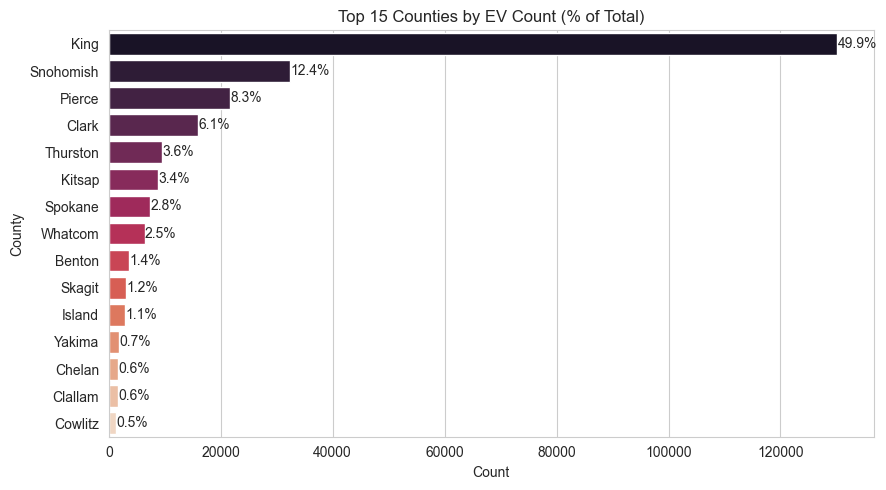

In [ ]:
county_counts = df['county'].astype(str).str.title().value_counts()
top15 = county_counts.head(15)

# Convert to % of total
top15_pct = (top15 / county_counts.sum() * 100).round(2)


plt.figure(figsize=(9,5))
sns.barplot(x=top15.values, y=top15.index, palette='rocket')

# Annotate with %
for i, (val, pct) in enumerate(zip(top15.values, top15_pct.values)):
    plt.text(val+50, i, f"{pct:.1f}%", va='center')

plt.title('Top 15 Counties by EV Count (% of Total)')
plt.xlabel('Count')
plt.ylabel('County')
plt.tight_layout()
plt.show()

### Insights
King County dominates adoption:
Accounts for 49.9% of all EVs in the dataset.
Indicates a hub of early adoption, likely driven by higher income levels, strong urban infrastructure, and proximity to major employers (e.g., tech hubs).
Next-tier counties (Snohomish, Pierce, Clark):
Combined, these three counties contribute another ~27% of the EV total.
Suggests a spillover effect from the urban center (King County).
Remaining counties (<5% each):
EV presence is diffuse but growing, with counties like Spokane, Whatcom, and Thurston showing moderate uptake.
Smaller, rural counties (Chelan, Clallam, Cowlitz) represent <1% each, highlighting gaps in adoption.

### Business Implications
Infrastructure Planning:
Nearly half of EVs are in one county, so charging infrastructure investment should prioritize King County to support demand.
Secondary focus should be on Snohomish, Pierce, and Clark, which are high-growth but underserved relative to King.
Policy Targeting:
Rural counties lag in adoption, suggesting the need for incentives, outreach, and charging availability to encourage uptake.
Market Strategy:
Automakers, dealerships, and charging providers can cluster sales and service operations in the top counties to maximize ROI.

# Top 20 Cities by EV Count (with % Contribution)

In [ ]:
# Count EVs by city
city_counts = df['city'].astype(str).str.title().value_counts()
top20 = city_counts.head(20)
top20_pct = (top20 / city_counts.sum() * 100).round(2)

city_df = pd.DataFrame({'city': top20.index,
                        'Count': top20.values,
                        'Pct of Total': top20_pct.values}).sort_values("Count", ascending=True)

print(city_df)
print("Plotted attractive lollipop chart for Top 20 Cities with gradient colors + % contribution")

             city  Count  Pct of Total
19      Snohomish   3003          1.15
18         Auburn   3063          1.17
17  Mercer Island   3089          1.18
16    Woodinville   3180          1.22
15       Issaquah   3904          1.50
14        Everett   4109          1.57
13       Lynnwood   4246          1.63
12        Spokane   4369          1.67
11     Bellingham   4376          1.68
10           Kent   4444          1.70
9          Tacoma   5749          2.20
8         Olympia   6166          2.36
7          Renton   7159          2.74
6       Sammamish   7265          2.78
5        Kirkland   7432          2.85
4         Bothell   8651          3.31
3         Redmond   8965          3.43
2       Vancouver   9665          3.70
1        Bellevue  12737          4.88
0         Seattle  41124         15.75
Plotted attractive lollipop chart for Top 20 Cities with gradient colors + % contribution


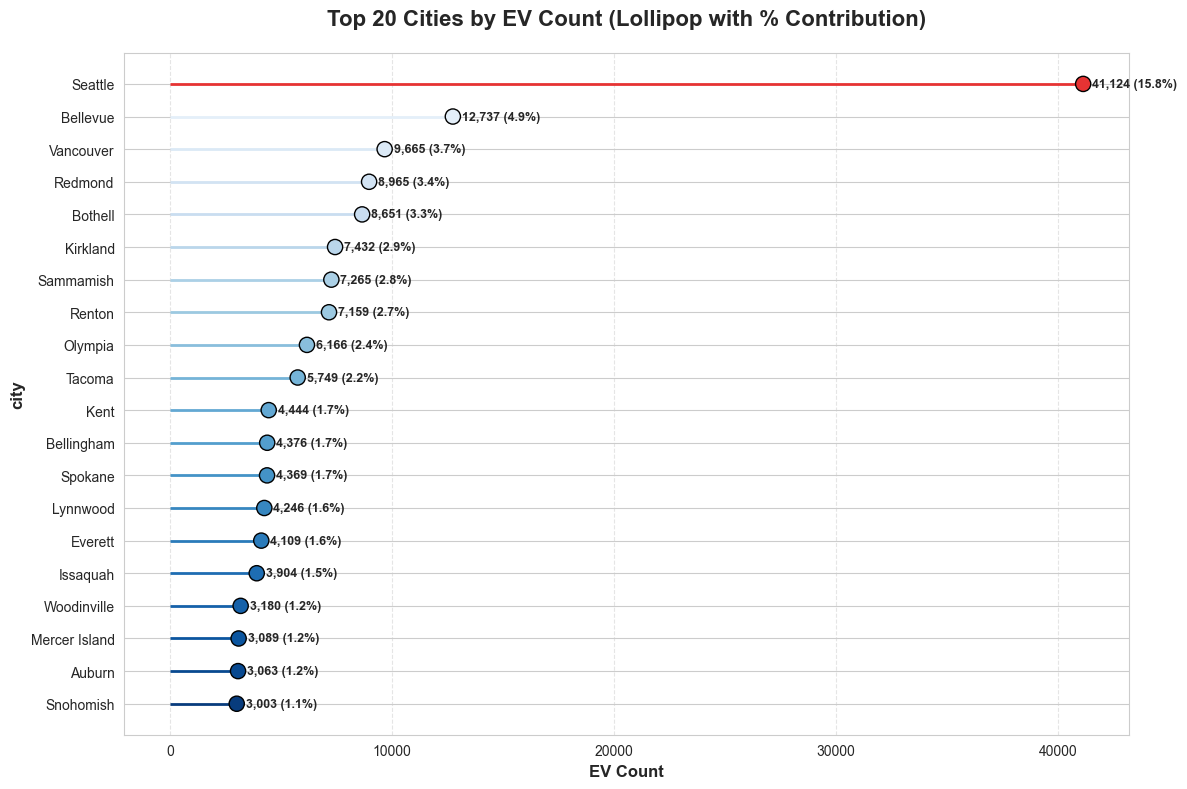

In [ ]:
# Color gradient (highlight top city separately)
colors = sns.color_palette("Blues_r", len(city_df))
colors[-1] = (0.9, 0.2, 0.2)  # red for the top city

plt.figure(figsize=(12,8))

# Stems (lines)
plt.hlines(y=city_df['city'], xmin=0, xmax=city_df['Count'],
           color=colors, linewidth=2)

# Points (circles)
plt.scatter(city_df['Count'], city_df['city'], 
            color=colors, s=120, edgecolor="black", zorder=3)

# Annotate counts + %
for count, city, pct in zip(city_df['Count'], city_df['city'], city_df['Pct of Total']):
    plt.text(count + city_df['Count'].max()*0.01, city, 
             f"{count:,} ({pct:.1f}%)", 
             va='center', fontsize=9, weight='bold')

# Style
plt.title("Top 20 Cities by EV Count (Lollipop with % Contribution)", 
          fontsize=16, weight='bold', pad=20)
plt.xlabel("EV Count", fontsize=12, weight='bold')
plt.ylabel("city", fontsize=12, weight='bold')
plt.grid(axis='x', linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Ev count with top 10 + (all others)

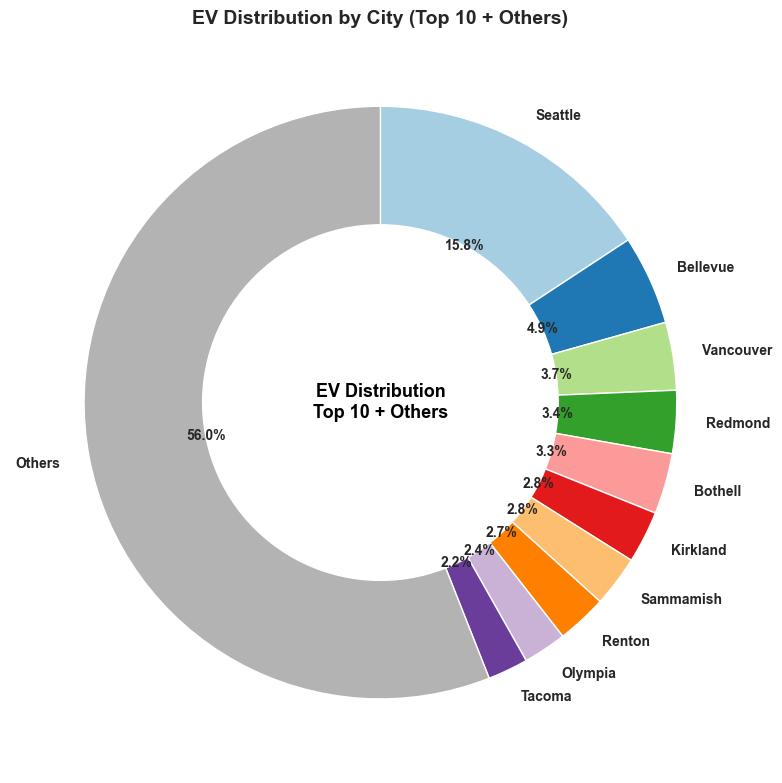

In [ ]:
# Count EVs by city
city_counts = df['city'].astype(str).str.title().value_counts()

# Top 10 + Others
top10 = city_counts.head(10)
others = city_counts.iloc[10:].sum()

# Combine
city_df = pd.DataFrame({'city': list(top10.index) + ['Others'],
                        'Count': list(top10.values) + [others]})
city_df['Pct of Total'] = (city_df['Count'] / city_counts.sum() * 100).round(2)

# Attractive color palette (bright colors + grey for "Others")
colors = sns.color_palette("Paired", 10) + [(0.7, 0.7, 0.7)]  # last one = grey

# Donut chart (clockwise)
plt.figure(figsize=(8,8))
wedges, texts, autotexts = plt.pie(city_df['Count'],
                                   labels=city_df['city'],
                                   autopct='%1.1f%%',
                                   startangle=90,
                                   counterclock=False,
                                   colors=colors,
                                   wedgeprops=dict(width=0.4),
                                   textprops={'fontsize':10, 'weight':'bold'})  # bold labels

# Title in center
plt.text(0, 0, 'EV Distribution\nTop 10 + Others', 
         ha='center', va='center', fontsize=13, weight='bold', color='black')

plt.title('EV Distribution by City (Top 10 + Others)', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()